In [2]:
#########################################
# Step 1. Imports
#########################################
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler, LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, LeakyReLU
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical
import tensorflow as tf
import arch
from arch.univariate import ConstantMean, GARCH, Normal
import keras_tuner as kt
from imblearn.over_sampling import RandomOverSampler
import keras.backend as K
import sys
sys.path.append('../Drafts')
from processing_module import round_hours

In [3]:
sol_prices = pd.read_parquet('../data/price_data/processed/sol_processed_data.parquet')
sol_features = pd.read_parquet('../Crypto_QTS_Data_Processed/sol_chain_processed.parquet')#.drop(columns=['average_difficulty','average_base_fee_per_gas','average_difficulty'])
sol_staking = pd.read_parquet('../data/on_chain_data/processed/sol_staking_data.parquet')
sol_tech = pd.read_parquet('../data/data_segmented_tech/sol_data.parquet')

sol_staking.index   = pd.to_datetime(sol_staking.index)
sol_features.index = pd.to_datetime(sol_features.index)

sol_prices['time_close'] = pd.to_datetime(sol_prices['time_close'])
sol_prices['time_close'] = sol_prices['time_close'].dt.tz_localize('UTC')
sol_prices.set_index('time_close', inplace=True)
sol_prices.index = sol_prices.index + pd.Timedelta(minutes=1)

sol_tech['time_close'] = pd.to_datetime(sol_tech['time_close'])
sol_tech['time_close'] = sol_tech['time_close'].dt.round('min')
sol_tech.set_index('time_close', inplace=True)

#########################################
# Step 3. Combine On-Chain Features
#########################################
df_combined = pd.concat([sol_features, sol_features]).sort_index()

#########################################
# Step 4. Align Staking Data with Combined Features
#########################################
common_start = max(sol_staking.index.min(), df_combined.index.min())
common_end   = min(sol_staking.index.max(), df_combined.index.max())

df1_aligned         = sol_staking.loc[common_start:common_end]
df_combined_aligned = df_combined.loc[common_start:common_end]

sol_features = pd.merge(
    df1_aligned, 
    df_combined_aligned, 
    left_index=True, 
    right_index=True, 
    how='inner'
)

#########################################
# Step 6. Clean and Align Price Data
#########################################
# Determine the global common time range across features, prices, and tech data
global_start = max(sol_features.index.min(), sol_prices.index.min(), sol_tech.index.min())
global_end   = min(sol_features.index.max(), sol_prices.index.max(), sol_tech.index.max())

sol_features_aligned = sol_features.loc[global_start:global_end]
sol_prices_aligned   = sol_prices.loc[global_start:global_end]

#########################################
# Step 7. Process and Align Technical Indicator Data
#########################################
# Subset tech data using the same global common time range
sol_tech_aligned = sol_tech.loc[global_start:global_end].copy()

# Ensure both DataFrames have unique indices by dropping duplicates
sol_prices_aligned = sol_prices_aligned[~sol_prices_aligned.index.duplicated(keep='first')]
sol_tech_aligned = sol_tech_aligned[~sol_tech_aligned.index.duplicated(keep='first')]

# Reindex the tech data to match the unique price data timestamps using nearest match
sol_tech_aligned = sol_tech_aligned.reindex(sol_prices_aligned.index, method='nearest')

tech_cols = ['fib_23', 'fib_38', 'fib_50', 'fib_61', 'fib_78', 'bollinger', 'EMAcross', 'RSI']
sol_tech_selected = sol_tech_aligned[tech_cols].rename(columns=lambda x: "tech_" + x)

#########################################
# Step 8. Join Price Data with Feature Data
#########################################

data = sol_features_aligned.join(
    sol_prices_aligned[['price_close']], 
    how='inner'
)

#########################################
# Step 9. Join Tech Features to Main Data
#########################################

data = data.join(sol_tech_selected, how='left')

#########################################
# Step 10. Unified Lag Adjustment for All Feature Columns
#########################################

lag_cols = [
    'average_total_transactions', 'average_successful_transactions', 'average_failed_transactions', 
    'average_total_vote_transactions', 'average_total_non_vote_transactions','average_successful_vote_transactions','average_successful_non_vote_transactions',
    'average_failed_vote_transactions', 'average_failed_non_vote_transactions',
    'staked_tokens', 'staking_ratio', 'total_staking_wallets','active_validators','real_reward_rate'
]
tech_cols_renamed = ["tech_" + col for col in tech_cols]
all_lag_cols = lag_cols + tech_cols_renamed

# Apply a lag of 1 to all feature columns (price_close remains unshifted)
print("Missing values per column:\n", data.isna().sum())
data[all_lag_cols] = data[all_lag_cols].shift(1)
print("Missing values per column:\n", data.isna().sum())

Missing values per column:
 active_validators                           0
real_reward_rate                            0
staked_tokens                               0
staking_ratio                               0
total_staking_wallets                       0
average_total_transactions                  0
average_successful_transactions             0
average_failed_transactions                 0
average_total_vote_transactions             0
average_total_non_vote_transactions         0
average_successful_vote_transactions        0
average_successful_non_vote_transactions    0
average_failed_vote_transactions            0
average_failed_non_vote_transactions        0
price_close                                 0
tech_fib_23                                 0
tech_fib_38                                 0
tech_fib_50                                 0
tech_fib_61                                 0
tech_fib_78                                 0
tech_bollinger                              0
tech_E

In [4]:
#########################################
# Step 3. Signal Generation
#########################################
# Compute price difference and its exponential moving average
data['price_diff'] = data['price_close'].diff()

THRESHOLD_MULTIPLIER = 0.5
threshold = data['price_diff'].std()  *0.5

# Define signal function
def get_signal(diff, threshold):
    if diff > threshold:
        return 'Buy'
    elif diff < -threshold:
        return 'Sell'
    else:
        return 'Hold'

# Apply signal generation and drop missing values
data['Signal'] = data['price_diff'].apply(lambda x: get_signal(x, threshold))
print("Missing values per column:\n", data.isna().sum())
data.dropna(inplace=True)
print("Missing values per column:\n", data.isna().sum())

Missing values per column:
 active_validators                           1
real_reward_rate                            1
staked_tokens                               1
staking_ratio                               1
total_staking_wallets                       1
average_total_transactions                  1
average_successful_transactions             1
average_failed_transactions                 1
average_total_vote_transactions             1
average_total_non_vote_transactions         1
average_successful_vote_transactions        1
average_successful_non_vote_transactions    1
average_failed_vote_transactions            1
average_failed_non_vote_transactions        1
price_close                                 0
tech_fib_23                                 1
tech_fib_38                                 1
tech_fib_50                                 1
tech_fib_61                                 1
tech_fib_78                                 1
tech_bollinger                              1
tech_E

In [ ]:
#########################################
# Step 4. Splitting data 70%/30%
#########################################
# Prepare features and target arrays
accuracy_train = []
accuracy_test = []

# Use only the lag-adjusted feature columns for training
X = data[all_lag_cols].values
y = data['Signal'].values

# Encode target labels
label_encoder = LabelEncoder()
integer_encoded = label_encoder.fit_transform(y)
y_cat = to_categorical(integer_encoded)

# Define the split index for 70% training data
split_index = int(0.7 * len(X))

# Split the data into training and testing sets
X_train = X[:split_index]
y_train = y_cat[:split_index]
X_test = X[split_index:]
y_test = y_cat[split_index:]

scaler = StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

# Calculate class weights
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Get the original labels (not one-hot encoded) for training set
y_train_labels = label_encoder.inverse_transform(np.argmax(y_train, axis=1))

# Compute class weights
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_labels),
    y=y_train_labels
)

# Create a dictionary of class weights
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

# Build the model
model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(64),
    LeakyReLU(negative_slope=0.1),
    Dense(32),
    LeakyReLU(negative_slope=0.1),
    Dense(y_cat.shape[1], activation='softmax')
])
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model with class weights
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test),
    class_weight=class_weight_dict,
    verbose=0
)

# Evaluate the model on the test set
score_2 = model.evaluate(X_train, y_train, verbose=0)
scores = model.evaluate(X_test, y_test, verbose=0)
print(f"Train accuracy: {score_2[1]*100:.2f}%")
accuracy_train.append(score_2[1])
print(f"Test accuracy: {scores[1]*100:.2f}%")
accuracy_test.append(scores[1])
best_model = model

In [ ]:
y_train_pred_prob = best_model.predict(X_train)
y_test_pred_prob = best_model.predict(X_test)

y_train_pred = np.argmax(y_train_pred_prob, axis=1)
y_test_pred = np.argmax(y_test_pred_prob, axis=1)

list_len = len(y_test_pred_prob)

prob_0 = np.zeros(list_len)
prob_1 = np.zeros(list_len)
prob_2 = np.zeros(list_len)

for i, row in enumerate(y_test_pred_prob):
  prob_0[i] = row[0]
  prob_1[i] = row[1]
  prob_2[i] = row[2]

sol_preds = pd.DataFrame()

sol_preds['Probability Hold'] = prob_0
sol_preds['Probability Buy'] = prob_1
sol_preds['Probability Sell'] = prob_2
sol_preds['Prediction'] = y_test_pred

sol_preds.to_csv('sol_orders.csv')

NameError: name 'best_model' is not defined

In [ ]:
np.mean(accuracy_train)

np.float64(0.6385701298713684)

In [ ]:
np.mean(accuracy_test)

np.float64(0.29235509037971497)

Train accuracy: 64.60%
Test accuracy: 28.19%
589/589 ━━━━━━━━━━━━━━━━━━━━ 1s 978us/step


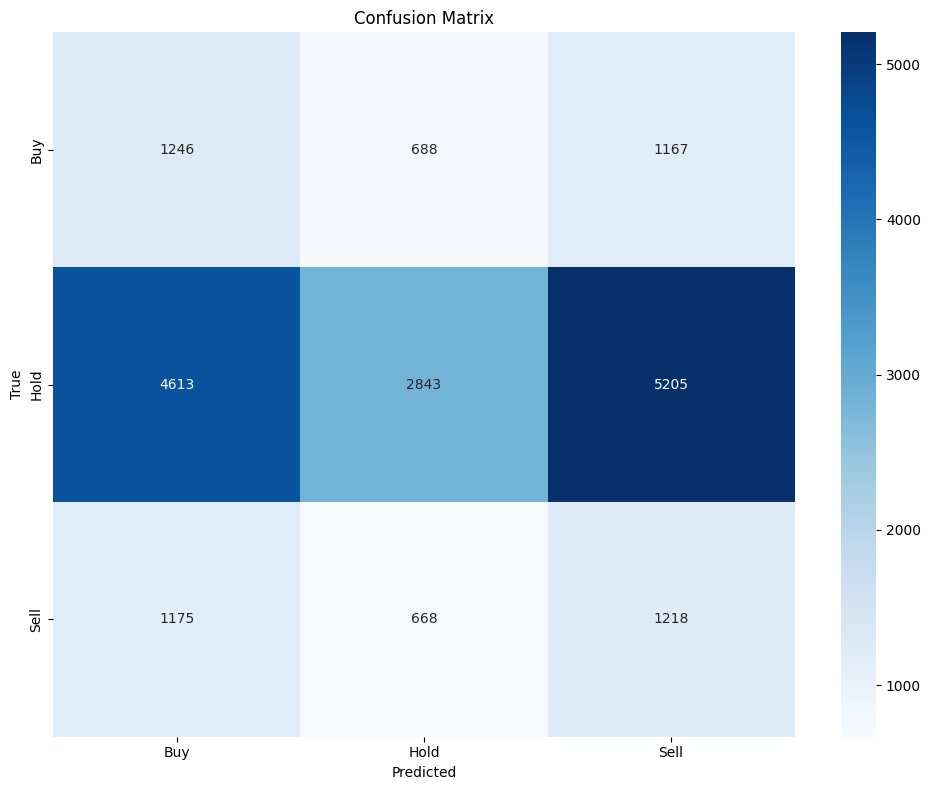


Classification Report:
              precision    recall  f1-score   support

         Buy       0.18      0.40      0.25      3101
        Hold       0.68      0.22      0.34     12661
        Sell       0.16      0.40      0.23      3061

    accuracy                           0.28     18823
   macro avg       0.34      0.34      0.27     18823
weighted avg       0.51      0.28      0.30     18823



In [ ]:
#########################################
# Step 4. Splitting data 70%/30%
#########################################
# Prepare features and target arrays

# Use only the lag-adjusted feature columns for training
X = data[all_lag_cols].values
y = data['Signal'].values

# Encode target labels
label_encoder = LabelEncoder()
integer_encoded = label_encoder.fit_transform(y)
y_cat = to_categorical(integer_encoded)

# Define the split index for 70% training data
split_index = int(0.7 * len(X))

# Split the data into training and testing sets
X_train = X[:split_index]
y_train = y_cat[:split_index]
X_test = X[split_index:]
y_test = y_cat[split_index:]

scaler = StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

# Calculate class weights
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Get the original labels (not one-hot encoded) for training set
y_train_labels = label_encoder.inverse_transform(np.argmax(y_train, axis=1))

# Compute class weights
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_labels),
    y=y_train_labels
)

# Create a dictionary of class weights
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

# Build the model
model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(64),
    LeakyReLU(negative_slope=0.1),
    Dense(32),
    LeakyReLU(negative_slope=0.1),
    Dense(y_cat.shape[1], activation='softmax')
])
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model with class weights
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test),
    class_weight=class_weight_dict,
    verbose=0
)

# Evaluate the model on the test set
score_2 = model.evaluate(X_train, y_train, verbose=0)
scores = model.evaluate(X_test, y_test, verbose=0)
print(f"Train accuracy: {score_2[1]*100:.2f}%")
print(f"Test accuracy: {scores[1]*100:.2f}%")
best_model = model

#########################################
# Confusion Matrix
#########################################
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Get predictions
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_test_classes = np.argmax(y_test, axis=1)

# Get the original class names
class_names = label_encoder.classes_

# Create confusion matrix
cm = confusion_matrix(y_test_classes, y_pred_classes)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

# Print classification report
print("\nClassification Report:")
print(classification_report(
    y_test_classes,
    y_pred_classes,
    target_names=class_names
))

True \ Predicted
Buy
Hold
Sell
Buy (Actual)
38 (correct)
439 (wrong)
12 (wrong)
Hold (Actual)
216 (wrong)
8851 (correct)
69 (wrong)
Sell (Actual)
37 (wrong)
449 (wrong)
17 (correct


589/589 ━━━━━━━━━━━━━━━━━━━━ 1s 973us/step

Trading Performance on Test Data:
Total PnL (percentage): 17.85%
Absolute PnL: $17,852.94
Annualized Sharpe Ratio: 0.0985


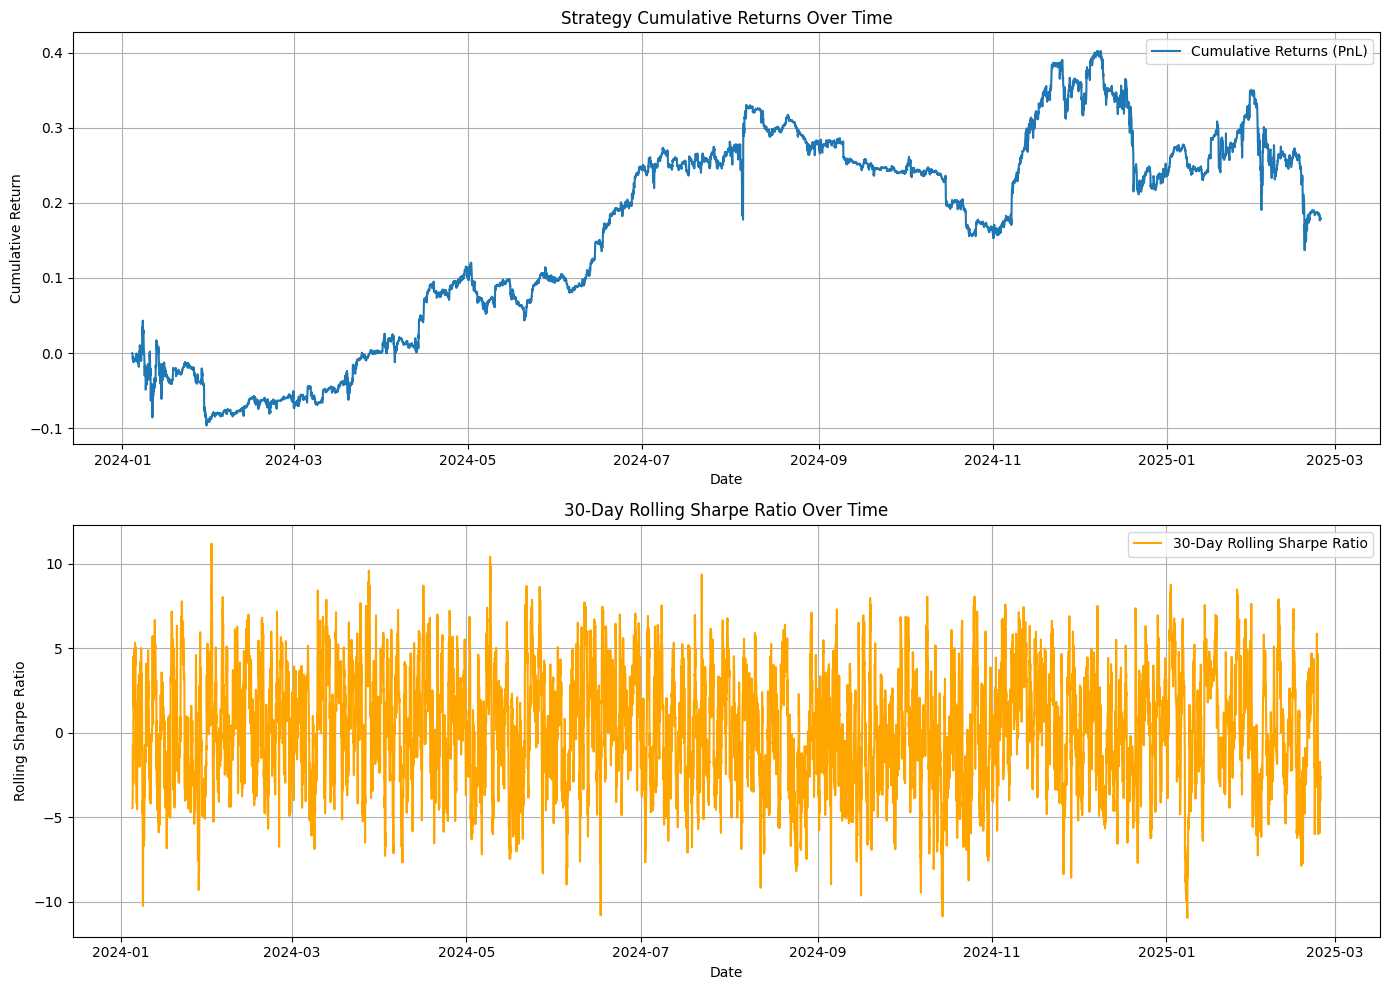

In [ ]:
# Define test_data from the combined data split
test_data = data.iloc[split_index:].copy()
test_data['asset_return'] = test_data['price_close'].pct_change()
test_data.dropna(inplace=True)

# Prepare test features and scale them
features_test_aligned = test_data[all_lag_cols].values
X_test_aligned = scaler.transform(features_test_aligned)

# Get prediction probabilities from the trained model
y_pred_test_aligned = best_model.predict(X_test_aligned)

# Define positions as the difference between probability of Buy (assumed index 0)
# and probability of Sell (assumed index 2)
positions_test_aligned = y_pred_test_aligned[:, 0] - y_pred_test_aligned[:, 2]

# Compute the strategy returns: assume positions are applied with a one-period lag
asset_returns_test = test_data['asset_return'].values.astype(np.float32)
strategy_returns_test = np.roll(positions_test_aligned, shift=1) * asset_returns_test
strategy_returns_test[0] = 0  # Set the first return to zero

# Calculate cumulative returns and performance metrics
cumulative_returns_test = np.cumprod(1 + strategy_returns_test) - 1
total_pnl_percentage = cumulative_returns_test[-1]
sharpe_ratio_test = (np.mean(strategy_returns_test) / np.std(strategy_returns_test)) * np.sqrt(365)
initial_capital = 100000
absolute_pnl_test = total_pnl_percentage * initial_capital

print("\nTrading Performance on Test Data:")
print("Total PnL (percentage): {:.2%}".format(total_pnl_percentage))
print("Absolute PnL: ${:,.2f}".format(absolute_pnl_test))
print("Annualized Sharpe Ratio: {:.4f}".format(sharpe_ratio_test))

# Plot performance metrics
dates = test_data.index
cumulative_returns_series = pd.Series(cumulative_returns_test, index=dates)
returns_series = pd.Series(strategy_returns_test, index=dates)

window = 30
rolling_sharpe = returns_series.rolling(window=window).apply(
    lambda r: (np.mean(r) / np.std(r) * np.sqrt(365)) if np.std(r) != 0 else 0,
    raw=True
)

plt.figure(figsize=(14, 10))

plt.subplot(2, 1, 1)
plt.plot(cumulative_returns_series.index, cumulative_returns_series, label='Cumulative Returns (PnL)')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.title('Strategy Cumulative Returns Over Time')
plt.legend()
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(rolling_sharpe.index, rolling_sharpe, label=f'{window}-Day Rolling Sharpe Ratio', color='orange')
plt.xlabel('Date')
plt.ylabel('Rolling Sharpe Ratio')
plt.title(f'{window}-Day Rolling Sharpe Ratio Over Time')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
#########################################
# Step 9. Run the model 10 more times and show each PnL, abs PnL, and annualized Sharpe
#########################################
num_runs = 10
total_pnl_list = []
absolute_pnl_list = []
sharpe_ratio_list = []

# List to store each newly trained model
model_list = []

for run in range(num_runs):
    print(f"\nTraining run {run+1}/{num_runs}")
    
    # Create a new instance of the same model architecture
    model_run = Sequential([
        Input(shape=(X_train.shape[1],)),
        Dense(64),
        LeakyReLU(negative_slope=0.1),
        Dense(32),
        LeakyReLU(negative_slope=0.1),
        Dense(y_cat.shape[1], activation='softmax')
    ])
    model_run.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    
    # Train the model for 50 epochs
    model_run.fit(
        X_train, y_train,
        epochs=50,
        batch_size=32,
        validation_split=0.2,
        verbose=0
    )
    scores_1 = model_run.evaluate(X_test, y_test, verbose=0)
    scores_2 = model_run.evaluate(X_train, y_train, verbose=0)
    print(f"Train accuracy: {scores_2[1]*100:.2f}%")
    print(f"Test accuracy: {scores_1[1]*100:.2f}%")
    # Store this newly trained model in a list
    model_list.append(model_run)
    
    # Evaluate on the test set
    test_data_run = test_data.copy()
    test_data_run['asset_return'] = test_data_run['price_close'].pct_change()
    strategy_data = test_data_run.dropna().copy()
    
    features_test_aligned = strategy_data[all_lag_cols].values
    X_test_aligned = scaler.transform(features_test_aligned)
    
    y_pred_test_aligned = model_run.predict(X_test_aligned)
    
    # Define positions as the difference between probability of Buy (index 0) and Sell (index 2)
    positions_test_aligned = y_pred_test_aligned[:, 0] - y_pred_test_aligned[:, 2]
    
    asset_returns_test = strategy_data['asset_return'].values.astype(np.float32)
    strategy_returns_test = np.roll(positions_test_aligned, shift=1) * asset_returns_test
    strategy_returns_test[0] = 0  # adjust the first value
    
    cumulative_returns_test = np.cumprod(1 + strategy_returns_test) - 1
    total_pnl_percentage = cumulative_returns_test[-1]
    
    # Compute Sharpe ratio; handle zero standard deviation
    std_returns = np.std(strategy_returns_test)
    if std_returns != 0:
        sharpe_ratio_test = (np.mean(strategy_returns_test) / std_returns) * np.sqrt(365)
    else:
        sharpe_ratio_test = 0
        
    initial_capital = 100000
    absolute_pnl_test = total_pnl_percentage * initial_capital
    
    print(f"Run {run+1} Trading Performance:")
    print("  Total PnL (percentage): {:.2%}".format(total_pnl_percentage))
    print("  Absolute PnL: ${:,.2f}".format(absolute_pnl_test))
    print("  Annualized Sharpe Ratio: {:.4f}".format(sharpe_ratio_test))
    
    total_pnl_list.append(total_pnl_percentage)
    absolute_pnl_list.append(absolute_pnl_test)
    sharpe_ratio_list.append(sharpe_ratio_test)

# Compute and display average results over all runs
avg_total_pnl = np.mean(total_pnl_list)
avg_absolute_pnl = np.mean(absolute_pnl_list)
avg_sharpe_ratio = np.mean(sharpe_ratio_list)

print("\nAverage Trading Performance over {} runs:".format(num_runs))
print("  Average Total PnL (percentage): {:.2%}".format(avg_total_pnl))
print("  Average Absolute PnL: ${:,.2f}".format(avg_absolute_pnl))
print("  Average Annualized Sharpe Ratio: {:.4f}".format(avg_sharpe_ratio))

# Now you have 10 separate model instances stored in model_list



Training run 1/10
Train accuracy: 84.84%
Test accuracy: 62.12%
589/589 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step  
Run 1 Trading Performance:
  Total PnL (percentage): -0.63%
  Absolute PnL: $-633.36
  Annualized Sharpe Ratio: 0.0068

Training run 2/10
Train accuracy: 84.84%
Test accuracy: 66.73%
589/589 ━━━━━━━━━━━━━━━━━━━━ 1s 992us/step
Run 2 Trading Performance:
  Total PnL (percentage): -1.30%
  Absolute PnL: $-1,295.94
  Annualized Sharpe Ratio: -0.0163

Training run 3/10
Train accuracy: 84.84%
Test accuracy: 65.77%
589/589 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Run 3 Trading Performance:
  Total PnL (percentage): -0.04%
  Absolute PnL: $-37.56
  Annualized Sharpe Ratio: 0.0097

Training run 4/10
Train accuracy: 84.84%
Test accuracy: 67.26%
589/589 ━━━━━━━━━━━━━━━━━━━━ 1s 966us/step
Run 4 Trading Performance:
  Total PnL (percentage): 1.03%
  Absolute PnL: $1,029.19
  Annualized Sharpe Ratio: 0.0219

Training run 5/10
Train accuracy: 84.84%
Test accuracy: 66.82%
589/589 ━━━━━━━━━━━━━━━━━━━━ 2s 

In [ ]:
avg_absolute_pnl

np.float32(3732.254)

In [ ]:
avg_total_pnl

np.float32(0.03732254)

In [ ]:
avg_sharpe_ratio

np.float64(0.04684920525125238)